In [1]:
import pandas as pd

In [ ]:
import numpy as np as plt

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

In [6]:
from sklearn.cluster import KMeans

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
print("Libraries loaded successfully")

Libraries loaded successfully


In [11]:
import pandas as pd

data = {
    "Customer_ID": range(1, 31),
    "Age": [19,21,20,23,31,35,40,28,22,30,25,29,33,37,24,27,32,41,26,38,23,34,45,36,28,31,39,22,30,27],
    "Gender": ["Female","Male","Female","Female","Male","Male","Female","Male","Female","Male",
               "Female","Male","Female","Male","Female","Male","Female","Male","Female","Male",
               "Female","Male","Female","Male","Female","Male","Female","Male","Female","Male"],
    "Annual_Income": [15,16,17,18,39,40,60,65,25,45,50,55,70,80,35,42,48,75,30,68,28,52,90,72,38,58,85,22,62,47],
    "Spending_Score": [39,81,6,77,40,60,42,55,76,65,45,72,50,35,80,58,64,30,75,48,85,52,25,40,70,62,20,90,55,68],
    "Purchase_Frequency": [2,8,1,7,4,6,5,6,8,7,4,7,5,3,9,6,7,3,8,5,9,6,2,4,7,6,2,10,6,8],
    "Product_Category": ["Fashion","Electronics","Grocery","Fashion","Beauty","Electronics","Fashion","Grocery","Beauty","Electronics",
                         "Fashion","Beauty","Electronics","Grocery","Fashion","Electronics","Beauty","Grocery","Fashion","Electronics",
                         "Beauty","Fashion","Electronics","Grocery","Beauty","Fashion","Electronics","Beauty","Grocery","Fashion"],
    "Total_Purchases": [5,18,2,15,8,12,10,13,17,14,9,16,11,6,20,13,15,7,18,10,21,12,5,8,16,14,4,22,13,19],
    "Avg_Order_Value": [500,1200,300,950,1500,1800,2200,1100,750,1600,900,1300,2000,850,1750,1400,1250,700,1550,1000,1900,1150,650,800,1450,1350,600,2100,1050,1650],
    "City": ["Delhi","Mumbai","Lucknow","Delhi","Pune","Mumbai","Lucknow","Delhi","Pune","Mumbai",
             "Delhi","Lucknow","Pune","Mumbai","Delhi","Pune","Lucknow","Delhi","Mumbai","Pune",
             "Delhi","Lucknow","Mumbai","Pune","Delhi","Mumbai","Lucknow","Delhi","Pune","Mumbai"],
    "Customer_Rating": [4,5,2,5,4,4,5,4,5,4,3,5,4,3,5,4,5,3,5,4,5,4,2,3,5,4,2,5,4,5]
}

df = pd.DataFrame(data)

df

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Frequency,Product_Category,Total_Purchases,Avg_Order_Value,City,Customer_Rating
0,1,19,Female,15,39,2,Fashion,5,500,Delhi,4
1,2,21,Male,16,81,8,Electronics,18,1200,Mumbai,5
2,3,20,Female,17,6,1,Grocery,2,300,Lucknow,2
3,4,23,Female,18,77,7,Fashion,15,950,Delhi,5
4,5,31,Male,39,40,4,Beauty,8,1500,Pune,4
5,6,35,Male,40,60,6,Electronics,12,1800,Mumbai,4
6,7,40,Female,60,42,5,Fashion,10,2200,Lucknow,5
7,8,28,Male,65,55,6,Grocery,13,1100,Delhi,4
8,9,22,Female,25,76,8,Beauty,17,750,Pune,5
9,10,30,Male,45,65,7,Electronics,14,1600,Mumbai,4


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Customer_ID         30 non-null     int64
 1   Age                 30 non-null     int64
 2   Gender              30 non-null     str  
 3   Annual_Income       30 non-null     int64
 4   Spending_Score      30 non-null     int64
 5   Purchase_Frequency  30 non-null     int64
 6   Product_Category    30 non-null     str  
 7   Total_Purchases     30 non-null     int64
 8   Avg_Order_Value     30 non-null     int64
 9   City                30 non-null     str  
 10  Customer_Rating     30 non-null     int64
dtypes: int64(8), str(3)
memory usage: 2.7 KB


In [13]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
display(df.describe())

Dataset Shape: (30, 11)

Column Names:
Index(['Customer_ID', 'Age', 'Gender', 'Annual_Income', 'Spending_Score',
       'Purchase_Frequency', 'Product_Category', 'Total_Purchases',
       'Avg_Order_Value', 'City', 'Customer_Rating'],
      dtype='str')

First 5 Rows:


,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Frequency,Product_Category,Total_Purchases,Avg_Order_Value,City,Customer_Rating
0,1,19,Female,15,39,2,Fashion,5,500,Delhi,4
1,2,21,Male,16,81,8,Electronics,18,1200,Mumbai,5
2,3,20,Female,17,6,1,Grocery,2,300,Lucknow,2
3,4,23,Female,18,77,7,Fashion,15,950,Delhi,5
4,5,31,Male,39,40,4,Beauty,8,1500,Pune,4



Missing Values:
Customer_ID           0
Age                   0
Gender                0
Annual_Income         0
Spending_Score        0
Purchase_Frequency    0
Product_Category      0
Total_Purchases       0
Avg_Order_Value       0
City                  0
Customer_Rating       0
dtype: int64

Basic Statistics:


,Customer_ID,Age,Annual_Income,Spending_Score,Purchase_Frequency,Total_Purchases,Avg_Order_Value,Customer_Rating
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,15.500000,29.866667,48.233333,55.500000,5.700000,12.433333,1243.333333,4.066667
std,8.803408,6.856828,21.580137,20.594191,2.336369,5.315451,497.707388,0.980265
min,1.000000,19.000000,15.000000,6.000000,1.000000,2.000000,300.000000,2.000000
25%,8.250000,24.250000,31.250000,40.500000,4.000000,8.250000,862.500000,4.000000
50%,15.500000,29.500000,47.500000,56.500000,6.000000,13.000000,1225.000000,4.000000
75%,22.750000,34.750000,64.250000,71.500000,7.000000,16.000000,1587.500000,5.000000
max,30.000000,45.000000,90.000000,90.000000,10.000000,22.000000,2200.000000,5.000000


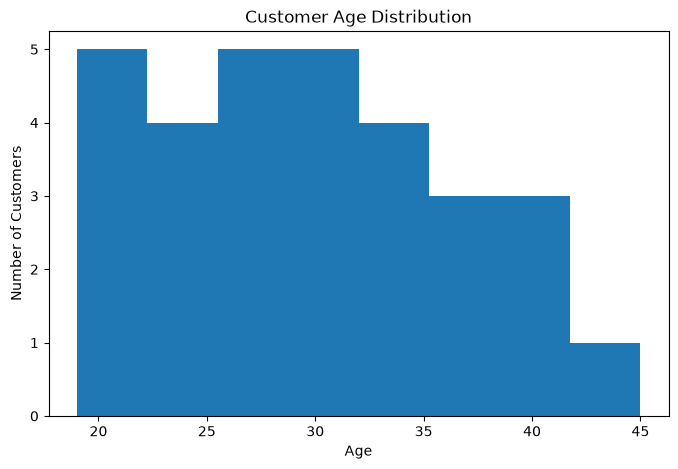

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=8)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customer Age Distribution")
plt.show()

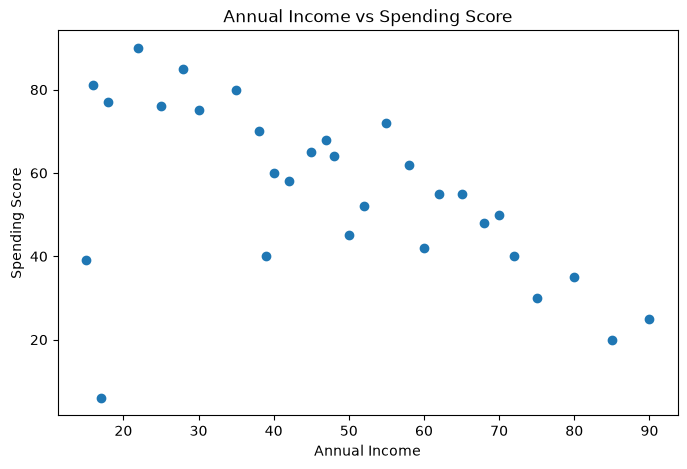

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df["Annual_Income"], df["Spending_Score"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Annual Income vs Spending Score")
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = [
    "Age",
    "Annual_Income",
    "Spending_Score",
    "Purchase_Frequency",
    "Total_Purchases",
    "Avg_Order_Value",
    "Customer_Rating"
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Frequency,Product_Category,Total_Purchases,Avg_Order_Value,City,Customer_Rating,Cluster
0,1,19,Female,15,39,2,Fashion,5,500,Delhi,4,2
1,2,21,Male,16,81,8,Electronics,18,1200,Mumbai,5,0
2,3,20,Female,17,6,1,Grocery,2,300,Lucknow,2,2
3,4,23,Female,18,77,7,Fashion,15,950,Delhi,5,0
4,5,31,Male,39,40,4,Beauty,8,1500,Pune,4,3


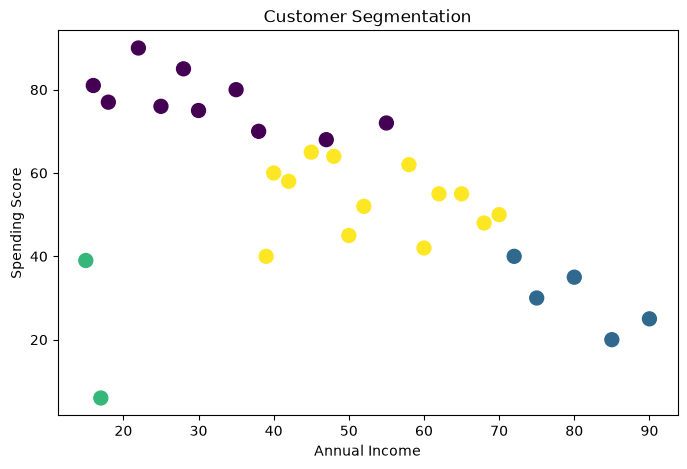

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"],
    s=100
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")
plt.show()

In [18]:
cluster_summary = df.groupby("Cluster").agg({
    "Age": "mean",
    "Annual_Income": "mean",
    "Spending_Score": "mean",
    "Purchase_Frequency": "mean",
    "Total_Purchases": "mean",
    "Avg_Order_Value": "mean",
    "Customer_Rating": "mean"
}).round(2)

cluster_summary

,Age,Annual_Income,Spending_Score,Purchase_Frequency,Total_Purchases,Avg_Order_Value,Customer_Rating
Cluster,,,,,,,
0,24.50,31.40,77.40,8.10,18.20,1460.00,5.00
1,39.60,80.40,30.00,2.80,6.00,720.00,2.60
2,19.50,16.00,22.50,1.50,3.50,400.00,3.00
3,31.85,53.77,53.54,5.62,11.85,1407.69,4.08


In [19]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print("Customers in Each Segment:")
print(cluster_counts)

Customers in Each Segment:
Cluster
0    10
1     5
2     2
3    13
Name: count, dtype: int64


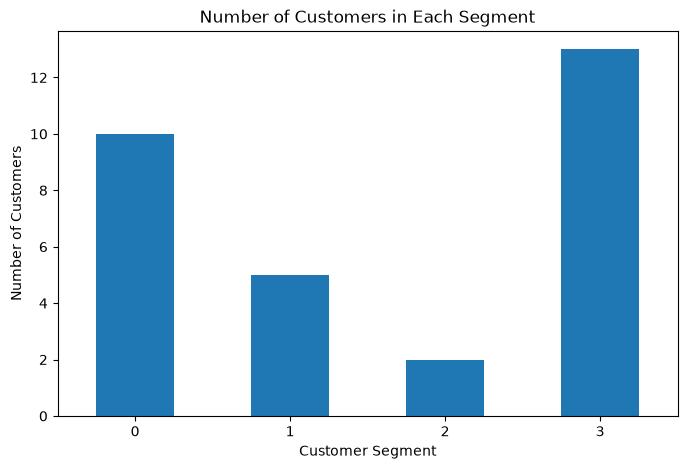

In [20]:
plt.figure(figsize=(8,5))

cluster_counts.plot(kind="bar")

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Segment")
plt.xticks(rotation=0)
plt.show()

In [21]:
print("CUSTOMER SEGMENTATION REPORT")
print("=" * 35)

for cluster in sorted(df["Cluster"].unique()):
    data = df[df["Cluster"] == cluster]
    
    print(f"\nSegment {cluster}")
    print("Customers:", len(data))
    print("Average Age:", round(data["Age"].mean(), 1))
    print("Average Income:", round(data["Annual_Income"].mean(), 1))
    print("Average Spending Score:", round(data["Spending_Score"].mean(), 1))
    print("Average Purchase Frequency:", round(data["Purchase_Frequency"].mean(), 1))

CUSTOMER SEGMENTATION REPORT

Segment 0
Customers: 10
Average Age: 24.5
Average Income: 31.4
Average Spending Score: 77.4
Average Purchase Frequency: 8.1

Segment 1
Customers: 5
Average Age: 39.6
Average Income: 80.4
Average Spending Score: 30.0
Average Purchase Frequency: 2.8

Segment 2
Customers: 2
Average Age: 19.5
Average Income: 16.0
Average Spending Score: 22.5
Average Purchase Frequency: 1.5

Segment 3
Customers: 13
Average Age: 31.8
Average Income: 53.8
Average Spending Score: 53.5
Average Purchase Frequency: 5.6


In [22]:
print("CONCLUSION")
print("=" * 30)
print("Customer segmentation was successfully performed using K-Means clustering.")
print("Customers were divided into 4 different segments based on their")
print("age, income, spending score, purchase frequency, purchases,")
print("average order value and customer rating.")
print("These segments can help businesses understand customer behavior")
print("and create targeted marketing strategies.")

CONCLUSION
Customer segmentation was successfully performed using K-Means clustering.
Customers were divided into 4 different segments based on their
age, income, spending score, purchase frequency, purchases,
average order value and customer rating.
These segments can help businesses understand customer behavior
and create targeted marketing strategies.


In [23]:
df.to_csv("customer_segmentation.csv", index=False)

print("Customer segmentation CSV saved successfully!")

Customer segmentation CSV saved successfully!
